<a href="https://colab.research.google.com/github/Prezzo-K/Graph-Neural-Networks-for-Fraud-Detection/blob/main/notebooks/Fraud_detection_dataset_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fraud-detection dataset Analysis**


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

na_chars=['.', ',', '-', '..', 'NA', 'None']
pd.set_option('display.max_rows', 21)
pd.set_option('display.max_columns', 21)
df=pd.read_csv('/content/Fraud Detection Transactions Dataset.csv',na_values=na_chars)
df


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TXN_11284,USER_4796,45.05,Online,2023-01-29 18:38:00,76960.11,Mobile,Tokyo,Clothing,0,0,2,389.00,3,Amex,98,1537.54,PIN,0.1493,1,0
49996,TXN_44732,USER_1171,126.15,POS,2023-05-09 08:55:00,28791.75,Mobile,Tokyo,Clothing,0,0,13,434.95,4,Visa,93,2555.72,Biometric,0.3653,0,1
49997,TXN_38158,USER_2510,72.02,Online,2023-01-30 19:32:00,29916.41,Laptop,Mumbai,Clothing,0,1,1,369.15,2,Visa,114,4686.59,Biometric,0.5195,0,0
49998,TXN_860,USER_2248,64.89,Bank Transfer,2023-03-09 19:47:00,67895.67,Mobile,Tokyo,Electronics,0,0,13,242.29,4,Discover,72,4886.92,Biometric,0.7063,0,1


# Analysis Process:

Basically I will try to handle my data cleaning process in 2 steps:

1. General Analysis via coding
* General Issues
    * duplicate datas
    * data type changing
    * removing heading and trailing spaces for string.
* Completeness Issues:
    * If any Nan value, handle those missing value
* Inaccurate data:
    * If there is any inaccurate data, like amount or balance being negative.
* Invalid data
    * accurate but not valid.
* inconsistent data, like Alias name for two products if any, or non-atomic attributes.

2. Manual Analysi if possible

# General Analysis

In [28]:
# Examining General and completeness issues:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

# **Observation: Problem**

**All total 50,000 tuple with 21 attributes**

* Transaction Amount at maximum only has 1174.14 value, so we can use float16 for this.
* Timstamp is datetime object but placed as string.
* Account_Balance highest recorded data is 99,998.31 ~ 1 million, So we can use float32 for storing this
* Card_Age is converted to int16
* risk_score is converted to float8
* is_weekend, ip_Address_flag, previous_fradulent_activity and fraud_level converted to boolean(True/False)

### **Completeness issue: NO issue in Completeness.**

### **Card_Age should be renamed to Card_Age_Month.**

### **No duplicate value in subset defined above**



In [29]:
# Check if duplicate is contained or not
df.duplicated(subset=['Transaction_ID','User_ID','Transaction_Amount','Account_Balance']).sum() # since sum is 0, there is no duplicate value

np.int64(0)

In [30]:
print(f'Max_transaction_amount: {df['Transaction_Amount'].max()}')
print(f'Max Account_Balance: {df['Account_Balance'].max()}')
print(f'Max Card_Age: {df['Card_Age'].max()}')

Max_transaction_amount: 1174.14
Max Account_Balance: 99998.31
Max Card_Age: 239


# **Detail Column wise analysis**

## **Issues**

 **Time_stamp column discuss with Abdi and Aaron, do they want me to divide the date into Year, Month ,day column or ..?**


In [31]:
# Transaction_Amount column
df[df['Transaction_Amount']<0] # no invalid transaction
df['Transaction_Amount'].describe()

,Transaction_Amount
count,50000.000000
mean,99.411012
std,98.687292
min,0.000000
25%,28.677500
50%,69.660000
75%,138.852500
max,1174.140000


In [32]:
df["Location"].unique() # unique locations

array(['Sydney', 'New York', 'Mumbai', 'Tokyo', 'London'], dtype=object)

<Axes: ylabel='Transaction_Amount'>

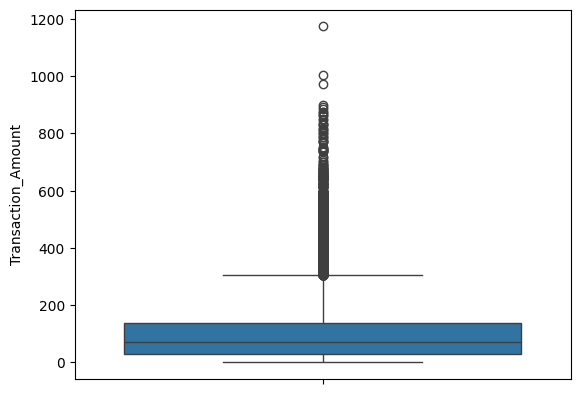

In [33]:
sns.boxplot(df['Transaction_Amount'])

## **OBSERVATION:Problem**

* I see 75 percentile of transaction is below 139, but maximum is above 1K.So, clerly looking at the box plot, I see 'Outlier'.

## **Should we deal with this or does this not affect model?**

In [34]:
# Transaction_Type column
print(df['Transaction_Type'].unique()) # No alias naming for transaction_type

print(f"There are {df['Transaction_ID'].count()} unique transactions in the dataset.")

['POS' 'Bank Transfer' 'Online' 'ATM Withdrawal']
There are 50000 unique transactions in the dataset.


In [35]:
# Account balance column
df[df['Account_Balance']<0] # no invalid account balance
df['Account_Balance'].describe() #looks no problem in quantiles and minimum maximum values.

,Account_Balance
count,50000.000000
mean,50294.065981
std,28760.458557
min,500.480000
25%,25355.995000
50%,50384.430000
75%,75115.135000
max,99998.310000


In [36]:
# Device_Type
df[df['Device_Type'].isna()]
df['Device_Type'].unique()

array(['Laptop', 'Mobile', 'Tablet'], dtype=object)

In [37]:
df[df['Location'].isna()]


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label


In [38]:
df['Location'].unique()

array(['Sydney', 'New York', 'Mumbai', 'Tokyo', 'London'], dtype=object)

In [39]:
df[df['Merchant_Category'].isna()]


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label


In [40]:
df['Merchant_Category'].unique()

array(['Travel', 'Clothing', 'Restaurants', 'Electronics', 'Groceries'],
      dtype=object)

## **Observation: Looks good**
---
### **Account Balance**: Data seems to be evenly spread looking at the percentile distribution
### **Device Type/Location/Merchant_Category**: Doesnot have any alias naming for any category. Like New York and NY kind of.


# **Profiling Using Ydata Profiling Package**

In [ ]:
import sys
!{sys.executable} -m pip install -U -q ydata-profiling[notebook]
!pip install -q jupyter-contrib-nbextensions

In [ ]:
!jupyter nbextension enable --py widgetsnbextension

In [ ]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport

# load dataset
dataset = pd.read_csv('/content/Fraud Detection Transactions Dataset.csv',na_values=na_chars)

# generate a profile
profile = ProfileReport(df = dataset,
                        title = "Fraud Transaction Dataset",
                        explorative=True
                        )

In [ ]:
profile

In [ ]:
help(profile)

In [ ]:
profile.to_file("index.html")

# Exploratory Data Analysis — Report Figures

The following sections present a structured EDA of the Fraud Detection Transactions Dataset (50,000 rows, 21 columns, 0 missing values). Each section is self-contained and produces publication-quality figures suitable for the project report and presentation.

In [ ]:
# CELL — Section 1: Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

# ── Global plot style ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.25)
mpl.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#cccccc",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.frameon": False,
    "font.family": "DejaVu Sans",
})

# ── Brand palette ──────────────────────────────────────────────────────────────
FRAUD_RED   = "#E74C3C"
LEGIT_GREEN = "#2ECC71"
PALETTE     = {0: LEGIT_GREEN, 1: FRAUD_RED}
LABEL_MAP   = {0: "Legitimate", 1: "Fraud"}

# ── Load data ──────────────────────────────────────────────────────────────────
DATA_PATH = "../data/Fraud Detection Transactions Dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["Timestamp"])

# ── Quick overview ─────────────────────────────────────────────────────────────
print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"\nFraud rate  : {df['Fraud_Label'].mean()*100:.1f}%  "
      f"({df['Fraud_Label'].sum():,} fraud / {(df['Fraud_Label']==0).sum():,} legit)\n")
print("─" * 60)
print("Data types:\n")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

In [ ]:
# CELL — Section 2: Dataset Overview

# ── 2a. Missing values bar chart ───────────────────────────────────────────────
missing = df.isnull().sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — all zeros confirms data quality
bar_colors = [FRAUD_RED if v > 0 else "#3498DB" for v in missing]
axes[0].bar(missing.index, missing.values, color=bar_colors, edgecolor="white", linewidth=0.6)
axes[0].set_title("Missing Values per Column")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Missing Count")
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_ylim(0, max(missing.max() + 1, 5))
axes[0].axhline(0, color="#cccccc", linewidth=0.8)
for i, (col, val) in enumerate(missing.items()):
    axes[0].text(i, val + 0.05, str(val), ha="center", va="bottom", fontsize=8.5, color="#555555")

# ── 2b. Data-types summary table rendered as a styled heatmap ─────────────────
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Dtype": [str(d) for d in df.dtypes],
    "Non-Null": df.notnull().sum().values,
    "Unique": [df[c].nunique() for c in df.columns],
}).set_index("Column")

axes[1].axis("off")
col_labels = ["Dtype", "Non-Null", "Unique Values"]
row_labels  = list(dtype_df.index)
cell_text   = dtype_df.values.tolist()

dtype_colors = []
dtype_color_map = {
    "float64": "#D6EAF8", "int64": "#D5F5E3",
    "object": "#FCF3CF",  "datetime64[ns]": "#F5EEF8",
    "bool": "#FDEBD0",
}
for row in dtype_df.itertuples():
    dtype_colors.append([
        dtype_color_map.get(row.Dtype, "#F2F3F4"),
        "#FDFEFE", "#FDFEFE"
    ])

tbl = axes[1].table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellColours=dtype_colors,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.35)
axes[1].set_title("Column Data Types Summary", pad=12)

plt.suptitle("Section 2 — Dataset Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── 2c. Statistical summary with gradient ─────────────────────────────────────
num_cols = df.select_dtypes(include="number").columns.tolist()
summary = df[num_cols].describe().T.round(3)
summary.insert(0, "Feature", summary.index)
summary = summary.reset_index(drop=True).set_index("Feature")

display(
    summary.style
    .background_gradient(cmap="Blues", axis=0, subset=["mean", "std"])
    .background_gradient(cmap="Greens", axis=0, subset=["min", "max"])
    .background_gradient(cmap="Oranges", axis=0, subset=["50%"])
    .format("{:.3f}")
    .set_caption("Descriptive Statistics — All Numerical Features")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"), ("text-align", "left")]},
        {"selector": "th",
         "props": [("background-color", "#2C3E50"), ("color", "white"),
                   ("font-size", "12px"), ("text-align", "center")]},
    ])
)

In [ ]:
# CELL — Section 3: Target Variable (Fraud Distribution)

fraud_counts = df["Fraud_Label"].value_counts().sort_index()
fraud_pcts   = df["Fraud_Label"].value_counts(normalize=True).sort_index() * 100
labels       = ["Legitimate (0)", "Fraud (1)"]
colors       = [LEGIT_GREEN, FRAUD_RED]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Pie chart ──────────────────────────────────────────────────────────────────
wedge_props = {"linewidth": 2, "edgecolor": "white"}
wedges, texts, autotexts = axes[0].pie(
    fraud_counts,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=wedge_props,
    explode=(0.03, 0.06),
    shadow=False,
    pctdistance=0.78,
    labeldistance=1.12,
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")
    at.set_color("white")
for t in texts:
    t.set_fontsize(12)
axes[0].set_title("Class Distribution — Pie Chart", pad=16)

# ── Count bar chart ────────────────────────────────────────────────────────────
bars = axes[1].bar(
    labels, fraud_counts.values,
    color=colors, edgecolor="white", linewidth=1.2, width=0.5
)
axes[1].set_title("Class Distribution — Count")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Transactions")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, count, pct in zip(bars, fraud_counts.values, fraud_pcts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#2C3E50"
    )

# Reference line at 50 %
axes[1].axhline(25000, color="#7F8C8D", linestyle="--", linewidth=1,
                label="50 % reference (25,000)")
axes[1].legend(loc="upper right")
axes[1].set_ylim(0, fraud_counts.max() * 1.18)

plt.suptitle("Section 3 — Target Variable: Fraud Label Distribution",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Legitimate transactions : {fraud_counts[0]:,}  ({fraud_pcts[0]:.1f}%)")
print(f"Fraudulent transactions : {fraud_counts[1]:,}  ({fraud_pcts[1]:.1f}%)")
print(f"Class imbalance ratio   : {fraud_counts[0]/fraud_counts[1]:.2f} : 1")

In [ ]:
# CELL — Section 4: Numerical Feature Distributions (KDE + Histogram)

num_features = [
    "Transaction_Amount", "Account_Balance",
    "Daily_Transaction_Count", "Avg_Transaction_Amount_7d",
    "Card_Age", "Transaction_Distance",
]
feature_labels = {
    "Transaction_Amount":       "Transaction Amount ($)",
    "Account_Balance":          "Account Balance ($)",
    "Daily_Transaction_Count":  "Daily Transaction Count",
    "Avg_Transaction_Amount_7d":"7-Day Avg Transaction Amount ($)",
    "Card_Age":                 "Card Age (months)",
    "Transaction_Distance":     "Transaction Distance (km)",
}

df_legit = df[df["Fraud_Label"] == 0]
df_fraud  = df[df["Fraud_Label"] == 1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    ax = axes[i]

    # Histogram + KDE for each class
    ax.hist(df_legit[feat], bins=50, density=True, alpha=0.35,
            color=LEGIT_GREEN, label="Legitimate", edgecolor="none")
    ax.hist(df_fraud[feat],  bins=50, density=True, alpha=0.35,
            color=FRAUD_RED,  label="Fraud",       edgecolor="none")

    # KDE curves
    for subset, color, label in [
        (df_legit, LEGIT_GREEN, "Legitimate"),
        (df_fraud,  FRAUD_RED,  "Fraud"),
    ]:
        kde_data = subset[feat].dropna()
        kde = stats.gaussian_kde(kde_data, bw_method="scott")
        x_range = np.linspace(kde_data.min(), kde_data.max(), 400)
        ax.plot(x_range, kde(x_range), color=color, linewidth=2.2, label=f"{label} KDE")

    ax.set_title(feature_labels[feat])
    ax.set_xlabel(feature_labels[feat])
    ax.set_ylabel("Density")

    # Clean legend — only show two entries (one per class)
    handles = [
        mpl.patches.Patch(facecolor=LEGIT_GREEN, alpha=0.7, label="Legitimate"),
        mpl.patches.Patch(facecolor=FRAUD_RED,   alpha=0.7, label="Fraud"),
    ]
    ax.legend(handles=handles, loc="upper right")

plt.suptitle("Section 4 — Numerical Feature Distributions by Fraud Label",
             fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# CELL — Section 5: Numerical Features vs Fraud (Violin Plots)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    ax = axes[i]

    # Build a compact two-class dataframe for seaborn
    plot_data = df[[feat, "Fraud_Label"]].copy()
    plot_data["Class"] = plot_data["Fraud_Label"].map(LABEL_MAP)

    sns.violinplot(
        data=plot_data,
        x="Class", y=feat,
        palette={"Legitimate": LEGIT_GREEN, "Fraud": FRAUD_RED},
        inner="quartile",        # show IQR lines inside
        linewidth=1.4,
        order=["Legitimate", "Fraud"],
        ax=ax,
        cut=0,
    )

    # Overlay means as diamonds
    for j, (cls, color) in enumerate(
        [("Legitimate", LEGIT_GREEN), ("Fraud", FRAUD_RED)]
    ):
        mean_val = plot_data[plot_data["Class"] == cls][feat].mean()
        ax.scatter(j, mean_val, marker="D", s=55, color="white",
                   edgecolor="#2C3E50", linewidth=1.5, zorder=5)

    ax.set_title(feature_labels[feat])
    ax.set_xlabel("Class")
    ax.set_ylabel(feature_labels[feat])

# Legend for mean marker
mean_marker = mpl.lines.Line2D(
    [], [], marker="D", color="white", markeredgecolor="#2C3E50",
    markeredgewidth=1.5, markersize=8, linestyle="None", label="Mean"
)
fig.legend(handles=[mean_marker], loc="upper right", bbox_to_anchor=(1.0, 1.0))

plt.suptitle("Section 5 — Numerical Features vs Fraud Label (Violin Plots)",
             fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# CELL — Section 6: Correlation Analysis

# Columns to include: all numerical, binary flags, and leakage columns, + Fraud_Label
corr_cols = [
    "Transaction_Amount", "Account_Balance", "Daily_Transaction_Count",
    "Avg_Transaction_Amount_7d", "Card_Age", "Transaction_Distance",
    "IP_Address_Flag", "Previous_Fraudulent_Activity", "Is_Weekend",
    "Risk_Score", "Failed_Transaction_Count_7d",
    "Fraud_Label",
]
corr_matrix = df[corr_cols].corr(method="pearson")

# ── 6a. Full correlation heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # upper triangle mask OFF — show full matrix
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="#e0e0e0",
    square=True,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.78, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix — Numerical & Binary Features",
             fontsize=15, fontweight="bold", pad=14)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0,  labelsize=10)
plt.tight_layout()
plt.show()

# ── 6b. Point-biserial correlation bar chart (feature vs Fraud_Label) ─────────
feature_cols = [c for c in corr_cols if c != "Fraud_Label"]
pb_corrs = {}
for col in feature_cols:
    r, p = stats.pointbiserialr(df["Fraud_Label"], df[col])
    pb_corrs[col] = r

pb_series = pd.Series(pb_corrs).sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [FRAUD_RED if v > 0 else LEGIT_GREEN for v in pb_series.values]
bars = ax.barh(pb_series.index, pb_series.values, color=bar_colors,
               edgecolor="white", linewidth=0.8, height=0.65)

ax.axvline(0, color="#2C3E50", linewidth=1.2)
ax.set_xlabel("Point-Biserial Correlation with Fraud_Label")
ax.set_title("Section 6b — Feature Correlation with Fraud Label\n(Point-Biserial r, sorted by magnitude)",
             fontsize=14, fontweight="bold")

# Annotate bars
for bar, val in zip(bars, pb_series.values):
    offset = 0.003 if val >= 0 else -0.003
    ha     = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=10, color="#2C3E50")

# Custom legend
pos_patch = mpl.patches.Patch(color=FRAUD_RED,   label="Positive correlation (higher → more fraud)")
neg_patch = mpl.patches.Patch(color=LEGIT_GREEN,  label="Negative correlation (higher → less fraud)")
ax.legend(handles=[pos_patch, neg_patch], loc="lower right")

ax.set_xlim(pb_series.min() - 0.08, pb_series.max() + 0.08)
plt.tight_layout()
plt.show()

In [ ]:
# CELL — Section 7: Categorical Features vs Fraud (Fraud Rate per Category)

cat_features = [
    "Transaction_Type", "Device_Type", "Location",
    "Merchant_Category", "Card_Type", "Authentication_Method",
]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ax = axes[i]

    fraud_rate = (
        df.groupby(feat)["Fraud_Label"]
        .mean()
        .mul(100)
        .sort_values(ascending=True)   # sort so longest bar is at top
    )

    # Colour bars by fraud rate intensity
    norm = plt.Normalize(fraud_rate.min(), fraud_rate.max())
    cmap = plt.cm.RdYlGn_r   # red = high fraud, green = low fraud
    bar_colors = [cmap(norm(v)) for v in fraud_rate.values]

    bars = ax.barh(fraud_rate.index, fraud_rate.values,
                   color=bar_colors, edgecolor="white", linewidth=0.8, height=0.55)

    # Reference line — overall fraud rate
    overall = df["Fraud_Label"].mean() * 100
    ax.axvline(overall, color="#2C3E50", linestyle="--", linewidth=1.3,
               label=f"Overall {overall:.1f}%")

    # Annotate bars
    for bar, val in zip(bars, fraud_rate.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", ha="left", fontsize=10, color="#2C3E50")

    ax.set_title(f"Fraud Rate by {feat.replace('_', ' ')}")
    ax.set_xlabel("Fraud Rate (%)")
    ax.set_ylabel(feat.replace("_", " "))
    ax.set_xlim(0, fraud_rate.max() + 6)
    ax.legend(fontsize=10)

plt.suptitle("Section 7 — Categorical Features vs Fraud Rate",
             fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()